# Focus scan
Image widths of one telescope over a focus scan: one pcap run per focuser step, each converted to
`<run>.pcapng.root.<board>` plus its pedestals/pedvars (`<run>.pcapng.root.pedvars`) using the pcap eventbuilding tools. Every image is
pedestal-subtracted, cleaned and parameterized with `heap.process_dataset.process_image()`, with a flat gain.
The best focus gives the narrowest images, so look for the step where the widths bottom out.

# Imports

In [32]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

from heap import diagnostics as dg
from heap import read_pcap
from heap.process_dataset import process_image

# Globals

In [ ]:
DATA_DIR = Path("/home/nkorzoun/research/PANOSETI/data/20261001")
TELESCOPE = "Winter"

# cleaning
IMAGE_THRESHOLD = 4.0
BORDER_THRESHOLD = 2.0
KEEP_BRIGHTEST_ISLAND = True # keep only the island with the largest summed signal
GAIN = np.ones((32, 32)) # flat

# cuts
MIN_NPIX = 3

# Read data

In [34]:
dfs = []
images = [] # cleaned images, row ImageIndex of df
for data_file in sorted(p for p in (DATA_DIR / TELESCOPE).rglob("*.root.T*") if p.suffix.startswith(".T")):
    pedvar_file = Path(f"{data_file}.pedvars") # calcPedestals() output
    if not pedvar_file.exists():
        pedvar_file = data_file.with_suffix(".pedvars") # widths-and-focus naming
    pedestal = read_pcap.read_tel_peds(pedvar_file)
    pedvar = read_pcap.read_tel_pedvars(pedvar_file)
    results = [
        process_image(image, pedestal, pedvar, GAIN, image_threshold=IMAGE_THRESHOLD, border_threshold=BORDER_THRESHOLD,
                      keep_brightest_island=KEEP_BRIGHTEST_ISLAND)
        for image in read_pcap.read_tel_data(data_file)
    ]
    images += [cleaned for cleaned, _ in results]
    params = pd.DataFrame([params for _, params in results])
    params.insert(0, "Timestamp", read_pcap.read_tel_timestamps(data_file))
    params.insert(0, "Event", np.arange(len(params)))
    params.insert(0, "File", data_file.name)
    params.insert(0, "Step", int(re.search(r"Focus(\d+)step", data_file.name).group(1)))
    dfs.append(params)

df = pd.concat(dfs, ignore_index=True)
df["ImageIndex"] = df.index
images = np.stack(images)
print(f"{len(df)} images in {df.Step.nunique()} steps")

989 images in 11 steps


In [35]:
df = df.dropna(subset=["length", "width", "miss", "distance", "alpha"])
df = df[df.width > 0]
df = df[df.N_pix >= MIN_NPIX].reset_index(drop=True)
print(f"{len(df)} after cuts")

466 after cuts


In [36]:
df.describe()

,Step,Event,Timestamp,N_pix,size,x_c,y_c,s_xx,s_yy,s_xy,length,width,miss,distance,alpha,phi
count,466.000000,466.000000,4.660000e+02,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000
mean,3653.004292,48.152361,1.790830e+09,8.690987,2125.856103,-0.000620,0.909550,0.062982,0.066628,-0.004691,0.288019,0.156488,2.266724,3.695383,43.845838,159.796960
std,903.280513,28.145023,9.240770e+02,6.805043,3430.503329,2.904127,2.524994,0.072262,0.178321,0.078303,0.140446,0.049890,1.500880,1.397635,26.498184,103.036136
min,2500.000000,0.000000,1.790828e+09,3.000000,168.730392,-4.732343,-4.743481,0.006774,0.005954,-1.505064,0.138400,0.059825,0.007171,0.329178,0.081575,0.502347
25%,2800.000000,23.000000,1.790829e+09,4.000000,548.530595,-2.596475,-1.121088,0.023717,0.023608,-0.013069,0.209363,0.115683,0.954374,2.641166,20.691164,66.649926
50%,3400.000000,49.000000,1.790829e+09,6.500000,1029.466017,0.219025,1.192633,0.044171,0.042179,-0.000081,0.254895,0.149571,2.108351,3.849128,43.909314,138.975831
75%,4300.000000,71.000000,1.790830e+09,11.000000,2176.307585,2.551818,3.045937,0.069228,0.072949,0.012193,0.330887,0.188522,3.359707,4.775547,66.182329,242.830381
max,5500.000000,108.000000,1.790832e+09,59.000000,47203.382965,4.735185,4.739626,0.764447,3.709300,0.208834,2.079731,0.404379,6.622832,6.665622,89.992748,358.609927


In [37]:
df

,Step,File,Event,Timestamp,N_pix,size,x_c,y_c,s_xx,s_yy,s_xy,length,width,miss,distance,alpha,phi
0,2500,PH_onskyFocus2500step__20261001_041700_312.pca...,0,1.790828e+09,3,318.366910,4.099314,1.502139,0.017931,0.021927,0.008494,0.169276,0.105848,2.280717,4.365867,31.493187,51.617873
1,2500,PH_onskyFocus2500step__20261001_041700_312.pca...,2,1.790828e+09,23,4428.247722,4.230710,4.202713,0.119763,0.271745,-0.061377,0.541697,0.313164,5.389326,5.963363,64.654028,109.463822
2,2500,PH_onskyFocus2500step__20261001_041700_312.pca...,3,1.790828e+09,5,478.153008,4.522909,-2.300644,0.072460,0.038620,0.038280,0.312078,0.116994,4.396251,5.074413,60.037973,33.077145
3,2500,PH_onskyFocus2500step__20261001_041700_312.pca...,4,1.790828e+09,9,720.448764,3.114192,2.990631,0.261396,0.050938,-0.070404,0.531767,0.171925,3.766498,4.317646,60.732882,343.107614
4,2500,PH_onskyFocus2500step__20261001_041700_312.pca...,5,1.790828e+09,17,2632.978086,4.416679,2.701296,0.172621,0.106978,0.000576,0.415483,0.327067,2.662469,5.177264,30.948128,0.502347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,5500,PH_onskyFocus5500step__20261001_050738_396.pca...,64,1.790832e+09,18,10167.091140,2.964875,3.143691,0.072341,0.145561,-0.030509,0.395735,0.247578,3.857984,4.321259,63.226169,109.902907
462,5500,PH_onskyFocus5500step__20261001_050738_396.pca...,65,1.790832e+09,4,650.506962,2.302076,-0.883837,0.032401,0.021967,-0.002013,0.181041,0.146942,0.447344,2.465912,10.451972,349.448643
463,5500,PH_onskyFocus5500step__20261001_050738_396.pca...,66,1.790832e+09,4,533.002529,1.254102,-1.994809,0.023653,0.043309,0.021517,0.239032,0.099124,2.133456,2.356276,64.882050,237.274811
464,5500,PH_onskyFocus5500step__20261001_050738_396.pca...,70,1.790832e+09,3,483.985466,-3.431178,0.688000,0.023141,0.019133,0.010819,0.179277,0.100665,2.723083,3.499475,51.090640,219.752377


# Widths

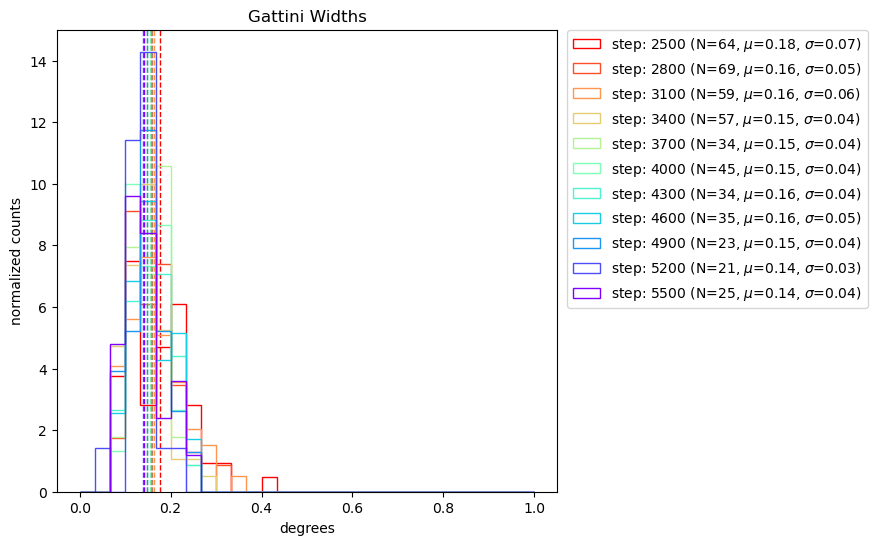

In [38]:
fig, ax = plt.subplots(figsize=(8,6))

steps = sorted(df.Step.unique())
cmap = plt.get_cmap('rainbow_r')
for i, step in enumerate(steps):
    color = cmap(i / max(1, len(steps)-1))

    data = df[df.Step==step]
    mean = data.width.mean()
    sigma = data.width.std()

    ax.hist(data.width, bins=30, range=(0,1), histtype='step', density=True,
            label=f"step: {step} (N={len(data)}, $\\mu$={mean:.2f}, $\\sigma$={sigma:.2f})", color=color)
    ax.axvline(mean, color=color, linestyle='--', linewidth=1)


ax.set_title(f'{TELESCOPE} Widths')
ax.set_xlabel('degrees')
ax.set_ylabel('normalized counts')

fig.subplots_adjust(right=0.75)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()

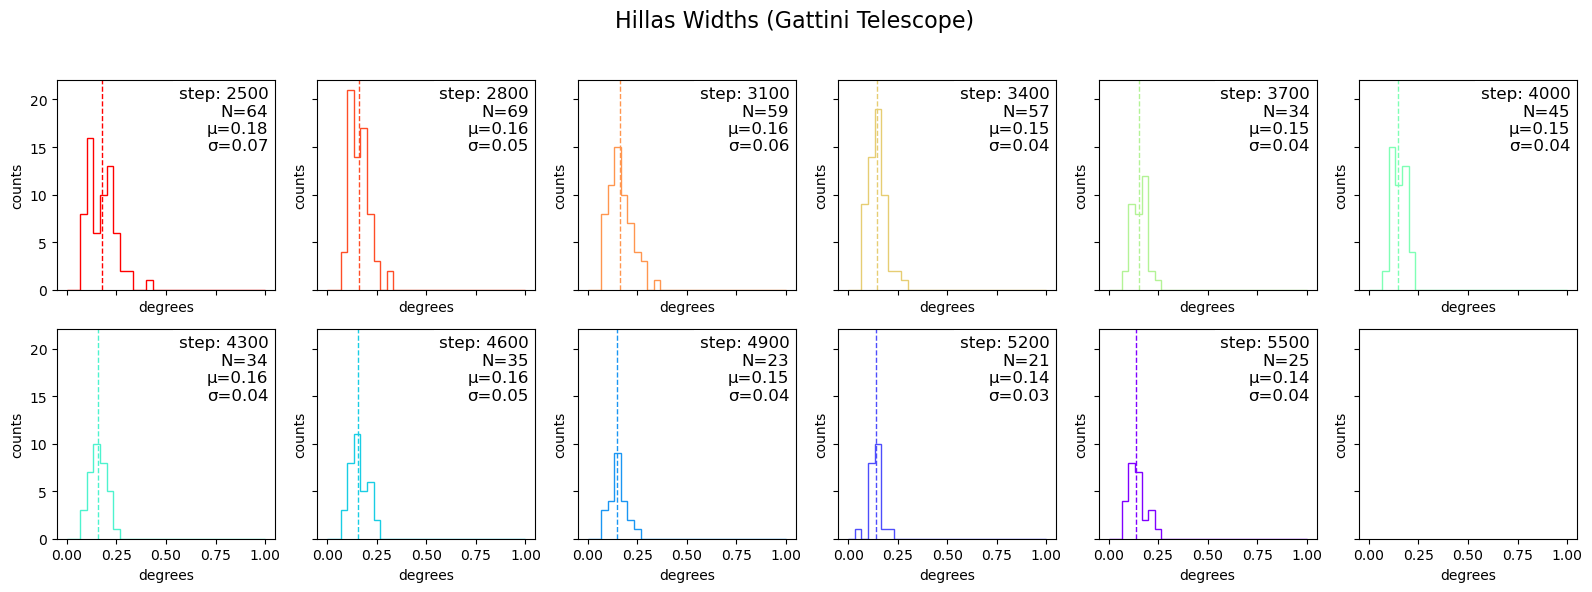

In [39]:
fig, axs = plt.subplots(2, int(np.ceil(df.Step.nunique()/2)), figsize=(16,6),sharex=True,sharey=True)
axs = axs.flatten()

steps = sorted(df.Step.unique())
cmap = plt.get_cmap('rainbow_r')
for i, step in enumerate(steps):
    color = cmap(i / max(1, len(steps)-1))

    data = df[df.Step==step]
    mean = data.width.mean()
    sigma = data.width.std()

    axs[i].hist(data.width, bins=30, range=(0,1), histtype='step', color=color)
    axs[i].axvline(mean, color=color, linestyle='--', linewidth=1)

    info = f"step: {step}\nN={len(data)}\nμ={mean:.2f}\nσ={sigma:.2f}"
    axs[i].text(0.97, 0.97, info, transform=axs[i].transAxes, ha='right', va='top', fontsize=12, color='k',
                bbox=dict(facecolor='white', alpha=0.75, edgecolor=None, linewidth=0))


fig.suptitle(f'Hillas Widths ({TELESCOPE} Telescope)',fontsize=16)

for ax in axs:
    ax.set_xlabel('degrees')
    ax.set_ylabel('counts')

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [40]:
stats = df.groupby("Step").width.agg(["count", "mean", "std", "sem"])
stats

,count,mean,std,sem
Step,,,,
2500,64,0.175647,0.068217,0.008527
2800,69,0.158906,0.048826,0.005878
3100,59,0.164337,0.059965,0.007807
3400,57,0.147584,0.043722,0.005791
3700,34,0.153546,0.039647,0.006799
4000,45,0.148912,0.037041,0.005522
4300,34,0.156491,0.040967,0.007026
4600,35,0.157001,0.045632,0.007713
4900,23,0.148628,0.038692,0.008068


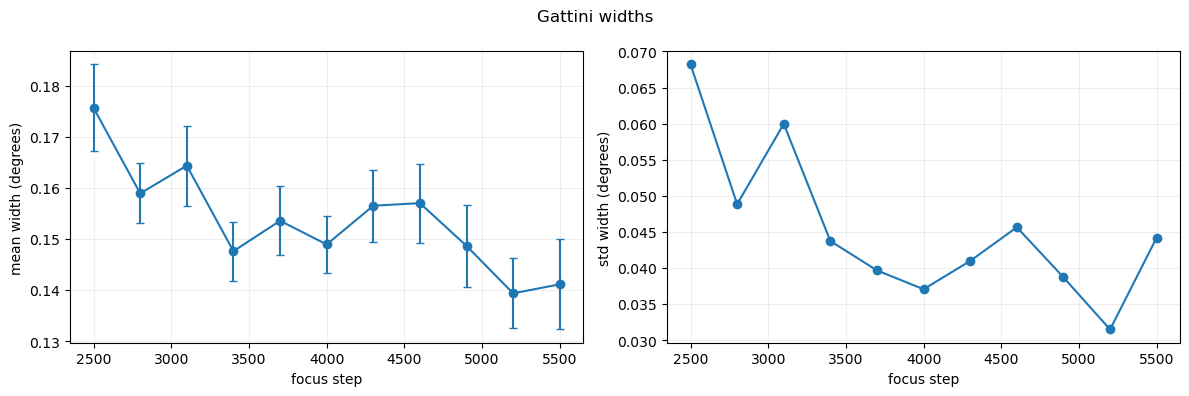

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
axs[0].errorbar(stats.index, stats["mean"], yerr=stats["sem"], marker="o", capsize=3)
axs[0].set(xlabel="focus step", ylabel="mean width (degrees)")
axs[1].plot(stats.index, stats["std"], marker="o")
axs[1].set(xlabel="focus step", ylabel="std width (degrees)")
for ax in axs:
    ax.grid(alpha=0.2)
fig.suptitle(f"{TELESCOPE} widths")
fig.tight_layout()
plt.show()

# Width vs distance

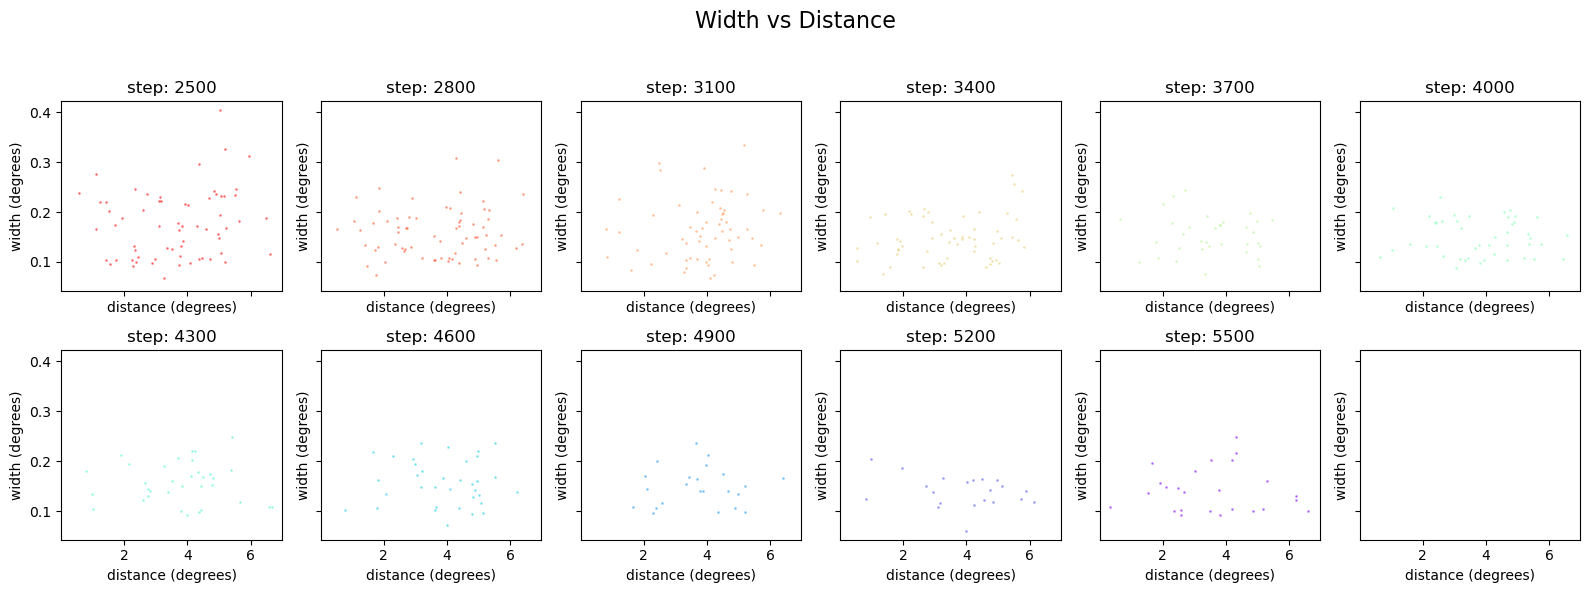

In [42]:
fig, axs = plt.subplots(2, int(np.ceil(df.Step.nunique()/2)), figsize=(16,6),sharex=True,sharey=True)
axs = axs.flatten()

steps = sorted(df.Step.unique())
cmap = plt.get_cmap('rainbow_r')
for i, step in enumerate(steps):
    color = cmap(i / max(1, len(steps)-1))

    data = df[df.Step==step]

    axs[i].scatter(data.distance,data.width, color=color, s=1, alpha=0.4)

    axs[i].set_title(f"step: {step}")


fig.suptitle('Width vs Distance',fontsize=16)

for ax in axs:
    ax.set_xlabel('distance (degrees)')
    ax.set_ylabel('width (degrees)')

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

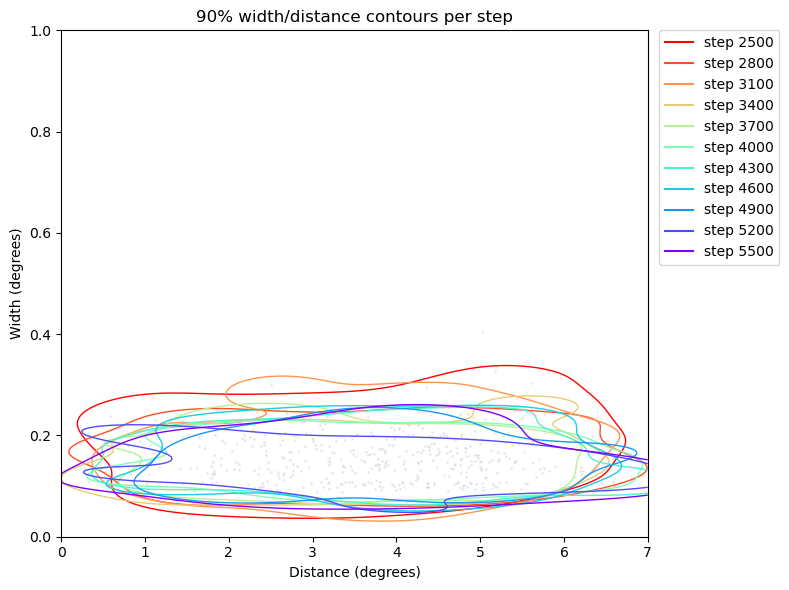

In [43]:
steps = sorted(df.Step.unique())
n_steps = len(steps)
cmap = plt.get_cmap('rainbow_r')

# common grid bounds
xmin, xmax = 0, 7
y_all = df.width.values
ymin, ymax = 0, 1

xi = np.linspace(xmin, xmax, 300)
yi = np.linspace(ymin, ymax, 300)
xx, yy = np.meshgrid(xi, yi)
positions = np.vstack([xx.ravel(), yy.ravel()])

fig, ax = plt.subplots(figsize=(8,6))

# faint background points
ax.scatter(df.distance, y_all, s=1, color='lightgray', alpha=0.4)

legend_handles = []

for i, step in enumerate(steps):
    data = df[df.Step == step]
    x = data.distance.values
    y = data.width.values
    if len(data) < 5:
        continue
    kde = gaussian_kde(np.vstack([x, y]))
    zz = np.reshape(kde(positions), xx.shape)

    # compute density thresholds for 68% and 90% mass
    zz_flat = zz.ravel()
    idx = np.argsort(zz_flat)[::-1]
    zz_sorted = zz_flat[idx]
    cumsum = np.cumsum(zz_sorted)
    cumsum /= cumsum[-1]
    level68 = zz_sorted[np.searchsorted(cumsum, 0.68)]
    level90 = zz_sorted[np.searchsorted(cumsum, 0.90)]

    color = cmap(i / max(1, n_steps-1))
    legend_handles.append(Line2D([0], [0], color=color, linestyle='solid', linewidth=1.5, label=f'step {step}'))

    # draw contours: 90% solid
    ax.contour(xx, yy, zz, levels=[level90], colors=[color], linestyles=['solid'], linewidths=1.0)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel('Distance (degrees)')
ax.set_ylabel('Width (degrees)')
ax.set_title('90% width/distance contours per step')

ax.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

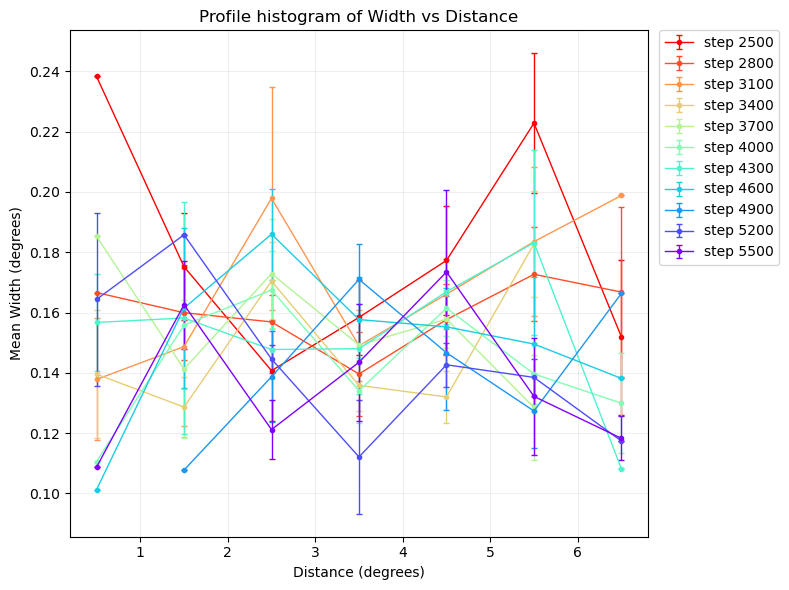

In [44]:
steps = sorted(df.Step.unique())
n_steps = len(steps)

fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.get_cmap('rainbow_r')

# profile histogram: mean width in distance bins
bin_width = 1  # degrees; change this to widen or narrow the bins
xmin, xmax = 0, 7
bin_edges = np.arange(xmin, xmax + bin_width, bin_width)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

for i, step in enumerate(steps):
    data = df[df.Step == step]
    if len(data) < 5:
        continue

    color = cmap(i / max(1, n_steps - 1))
    bin_index = np.digitize(data.distance.values, bin_edges) - 1

    means = []
    errors = []
    centers = []

    for b in range(len(bin_edges) - 1):
        mask = bin_index == b
        if not np.any(mask):
            continue
        widths = data.width.values[mask]
        centers.append(bin_centers[b])
        means.append(np.mean(widths))
        errors.append(np.std(widths) / np.sqrt(len(widths)) if len(widths) > 1 else 0.0)

    ax.errorbar(
        centers,
        means,
        yerr=errors,
        color=color,
        marker='o',
        markersize=3,
        linewidth=1,
        capsize=2,
        label=f'step {step}',
    )

ax.set_xlabel('Distance (degrees)')
ax.set_ylabel('Mean Width (degrees)')
ax.set_title('Profile histogram of Width vs Distance')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Brightness vs distance

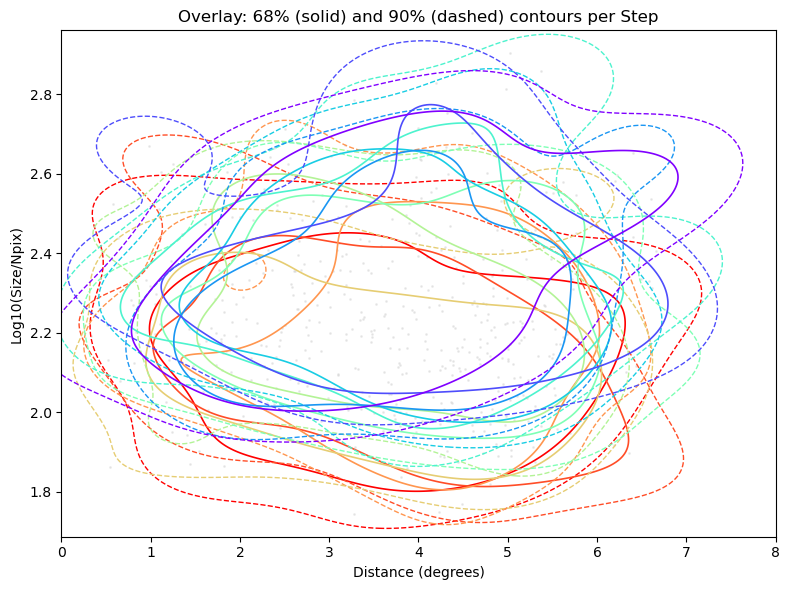

In [45]:
steps = sorted(df.Step.unique())
n_steps = len(steps)
cmap = plt.get_cmap('rainbow_r')

# common grid bounds
xmin, xmax = 0, 8
y_all = np.log10(df["size"].values / df.N_pix.values)
ymin, ymax = np.nanmin(y_all), np.nanmax(y_all)
ypad = 0.05 * (ymax - ymin) if ymax>ymin else 0.1
ymin -= ypad; ymax += ypad

xi = np.linspace(xmin, xmax, 300)
yi = np.linspace(ymin, ymax, 300)
xx, yy = np.meshgrid(xi, yi)
positions = np.vstack([xx.ravel(), yy.ravel()])

fig, ax = plt.subplots(figsize=(8,6))

# faint background points
ax.scatter(df.distance, y_all, s=1, color='lightgray', alpha=0.4)

for i, step in enumerate(steps):
    data = df[df.Step == step]
    x = data.distance.values
    y = np.log10(data["size"].values / data.N_pix.values)
    if len(data) < 5:
        continue
    kde = gaussian_kde(np.vstack([x, y]))
    zz = np.reshape(kde(positions), xx.shape)

    # compute density thresholds for 68% and 90% mass
    zz_flat = zz.ravel()
    idx = np.argsort(zz_flat)[::-1]
    zz_sorted = zz_flat[idx]
    cumsum = np.cumsum(zz_sorted)
    cumsum /= cumsum[-1]
    level68 = zz_sorted[np.searchsorted(cumsum, 0.68)]
    level90 = zz_sorted[np.searchsorted(cumsum, 0.90)]

    color = cmap(i / max(1, n_steps-1))

    # draw contours: 68% solid, 90% dashed
    ax.contour(xx, yy, zz, levels=[level68], colors=[color], linestyles=['solid'], linewidths=1.2)
    ax.contour(xx, yy, zz, levels=[level90], colors=[color], linestyles=['dashed'], linewidths=1.0)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel('Distance (degrees)')
ax.set_ylabel('Log10(Size/Npix)')
ax.set_title('Overlay: 68% (solid) and 90% (dashed) contours per Step')
plt.tight_layout()
plt.show()

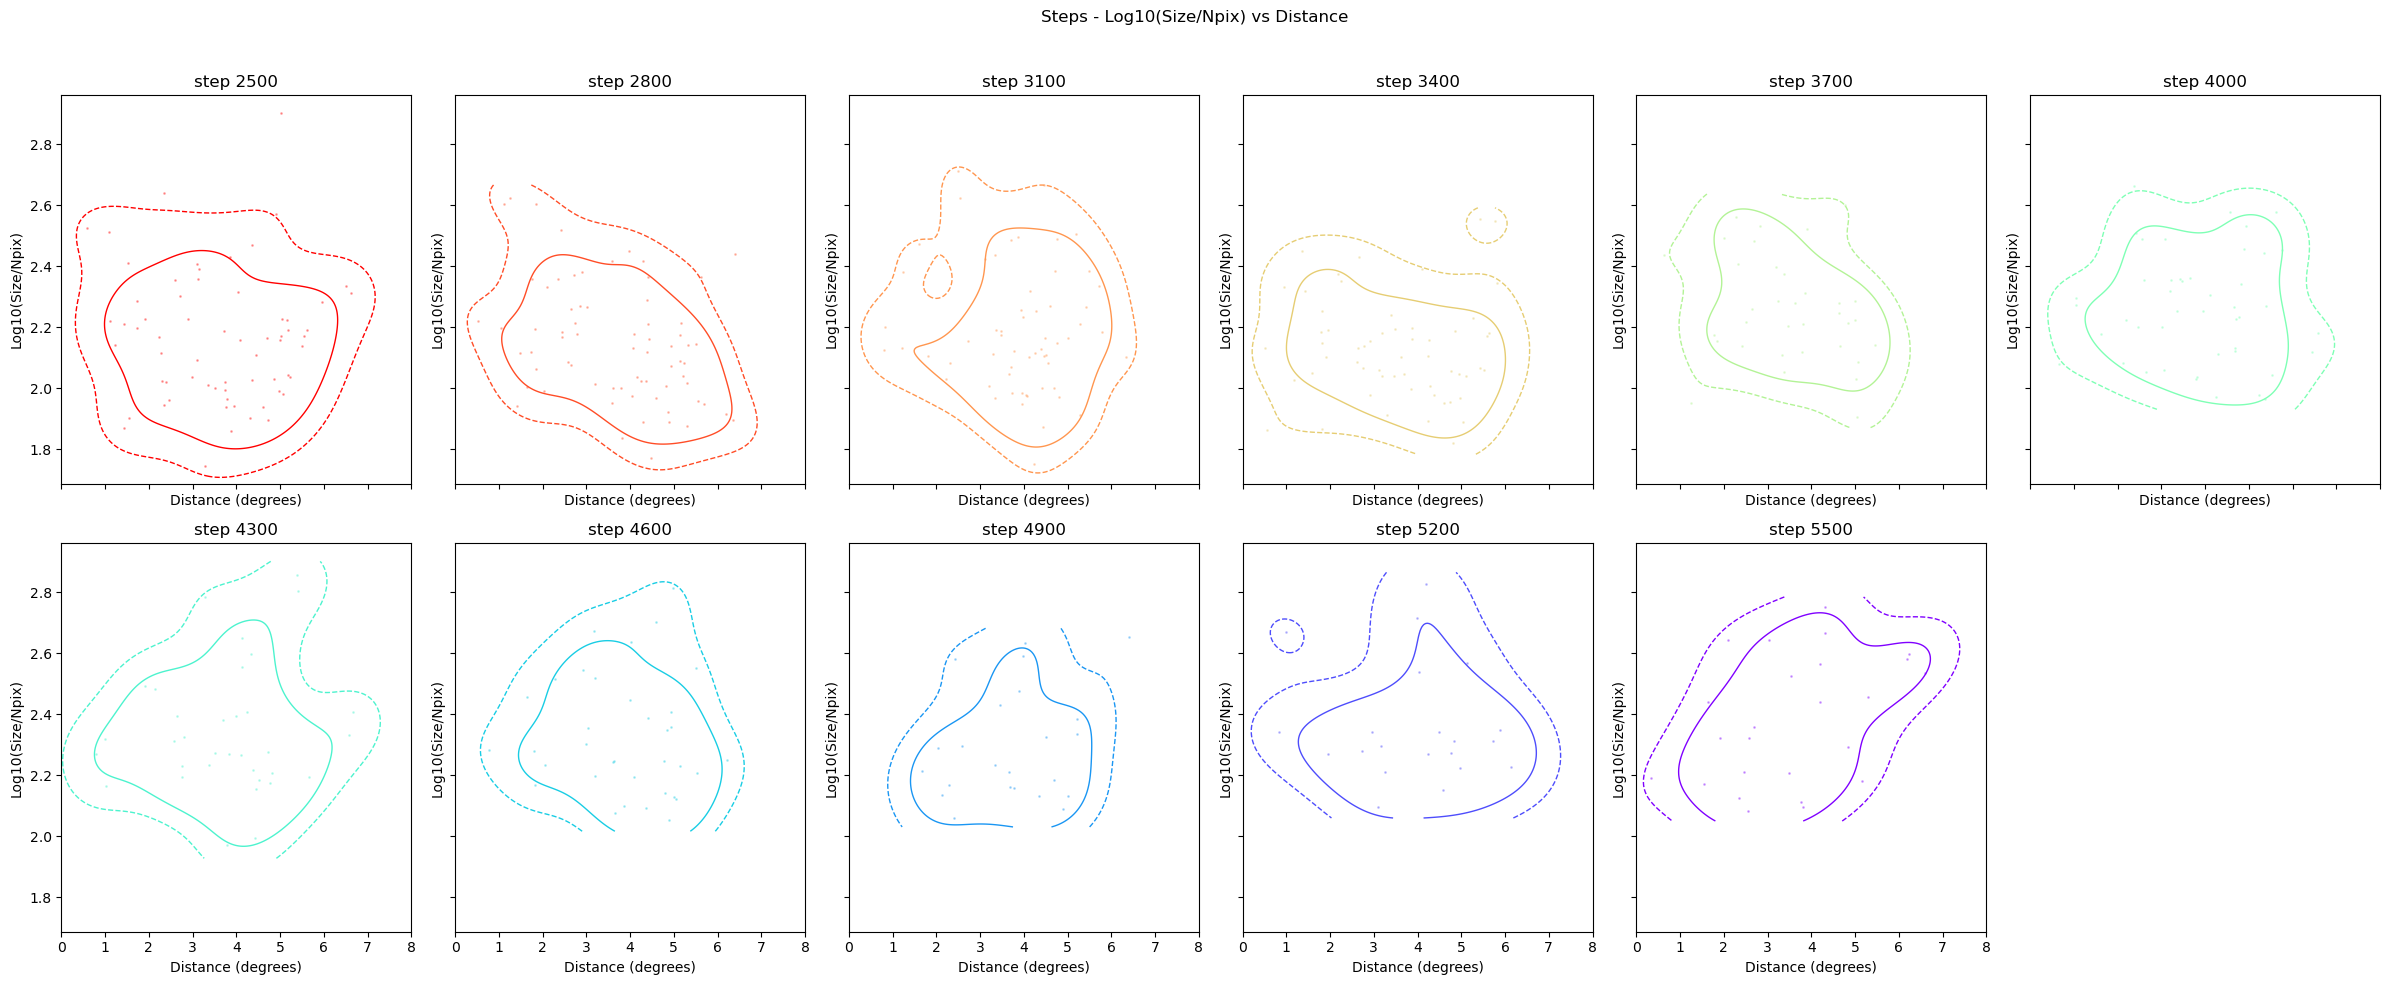

In [46]:
steps = sorted(df.Step.unique())
n_steps = len(steps)
ncols = int(np.ceil(n_steps/2))
fig, axs = plt.subplots(2, ncols, figsize=(4*ncols, 10), sharex=True, sharey=True)
axs = axs.flatten()
fig.suptitle("Steps - Log10(Size/Npix) vs Distance")

cmap = plt.get_cmap('rainbow_r')

for i, step in enumerate(steps):
    ax = axs[i]
    data = df[df.Step == step]
    x = data.distance.values
    y = np.log10(data["size"].values / data.N_pix.values)

    if len(data) < 5:
        ax.text(0.5,0.5,'too few points', transform=ax.transAxes, ha='center')
        ax.set_title(f"step {step}")
        continue

    # grid for KDE
    xmin, xmax = 0, 8
    ymin, ymax = np.nanmin(y), np.nanmax(y)
    ypad = 0.05 * (ymax - ymin) if ymax>ymin else 0.1
    ymin -= ypad; ymax += ypad
    xi = np.linspace(xmin, xmax, 200)
    yi = np.linspace(ymin, ymax, 200)
    xx, yy = np.meshgrid(xi, yi)
    positions = np.vstack([xx.ravel(), yy.ravel()])

    # compute KDE
    try:
        kde = gaussian_kde(np.vstack([x, y]))
    except Exception as e:
        ax.scatter(x, y, s=2, alpha=0.3)
        ax.set_title(f"step {step}")
        continue
    zz = np.reshape(kde(positions), xx.shape)

    # find contour levels for 68% and 90%
    zz_flat = zz.ravel()
    idx = np.argsort(zz_flat)[::-1]
    zz_sorted = zz_flat[idx]
    cumsum = np.cumsum(zz_sorted)
    cumsum /= cumsum[-1]
    level68 = zz_sorted[np.searchsorted(cumsum, 0.68)]
    level90 = zz_sorted[np.searchsorted(cumsum, 0.90)]

    color = cmap(i / max(1, n_steps-1))

    # scatter and unfilled contours
    ax.scatter(x, y, color=color, s=1, alpha=0.3)
    ax.contour(xx, yy, zz, levels=[level68], colors=[color], linestyles=['solid'], linewidths=1.0)
    ax.contour(xx, yy, zz, levels=[level90], colors=[color], linestyles=['dashed'], linewidths=1.0)

    ax.set_title(f"step {step}")
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel('Distance (degrees)')
    ax.set_ylabel('Log10(Size/Npix)')

# turn off unused axes
for j in range(n_steps, len(axs)):
    axs[j].axis('off')

fig.tight_layout(rect=[0,0,1,0.96])
plt.show()

# Events
Cleaned images after cuts with their Hillas ellipses; the panel title's number is the row in `df`. Run again for other random events.

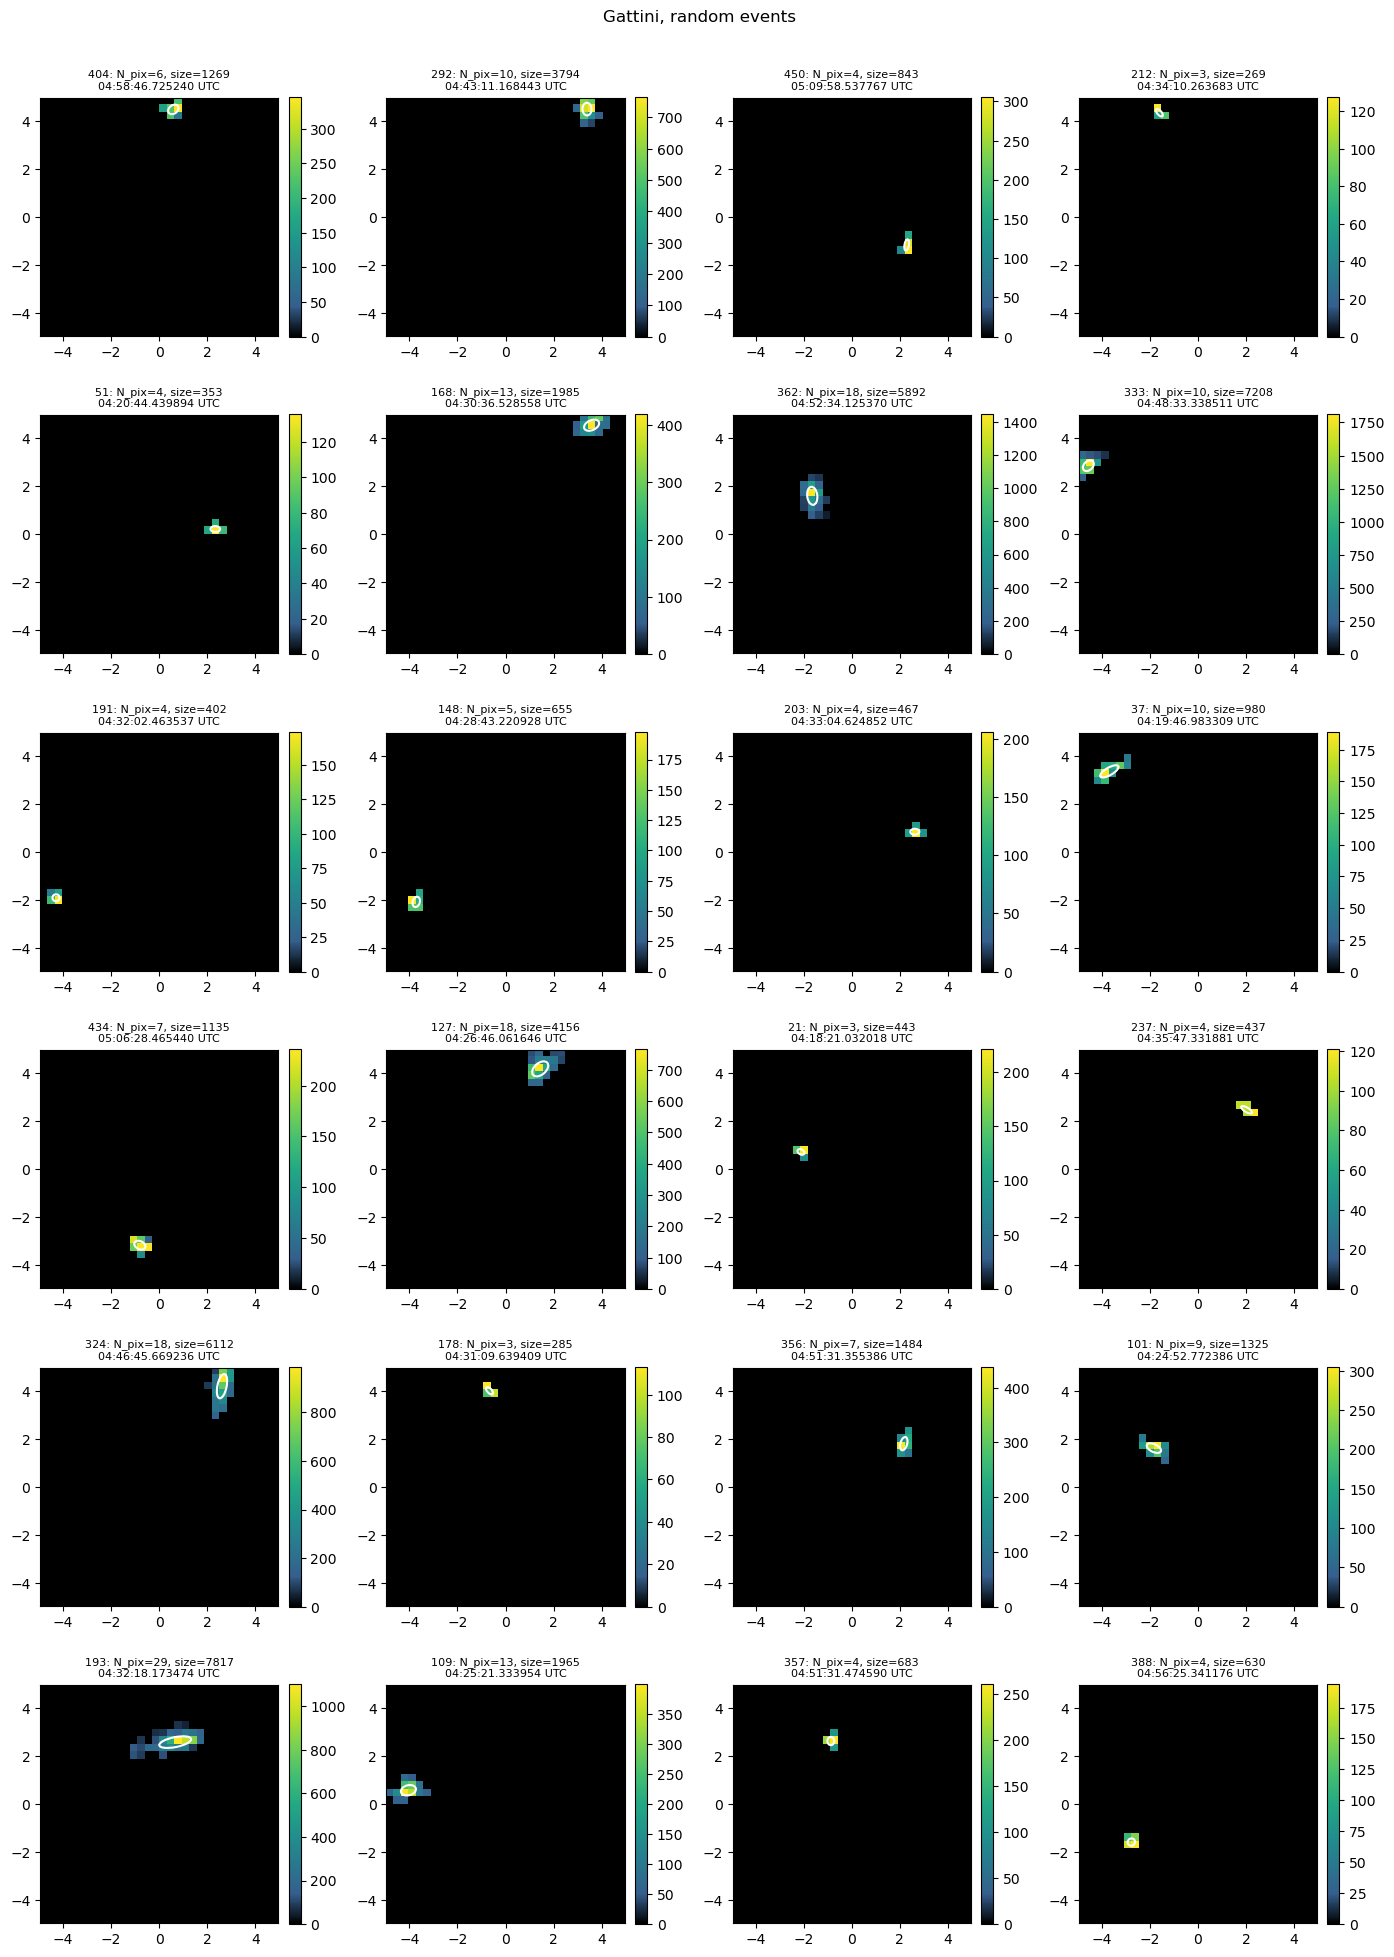

In [67]:
N_EVENTS = 24
cut_images = images[df.ImageIndex] # same rows as df

fig = dg.plot_image_grid(df, cut_images, np.random.default_rng().choice(len(df), size=min(N_EVENTS, len(df)), replace=False))
fig.suptitle(f"{TELESCOPE}, random events", y=1.02)
plt.show()

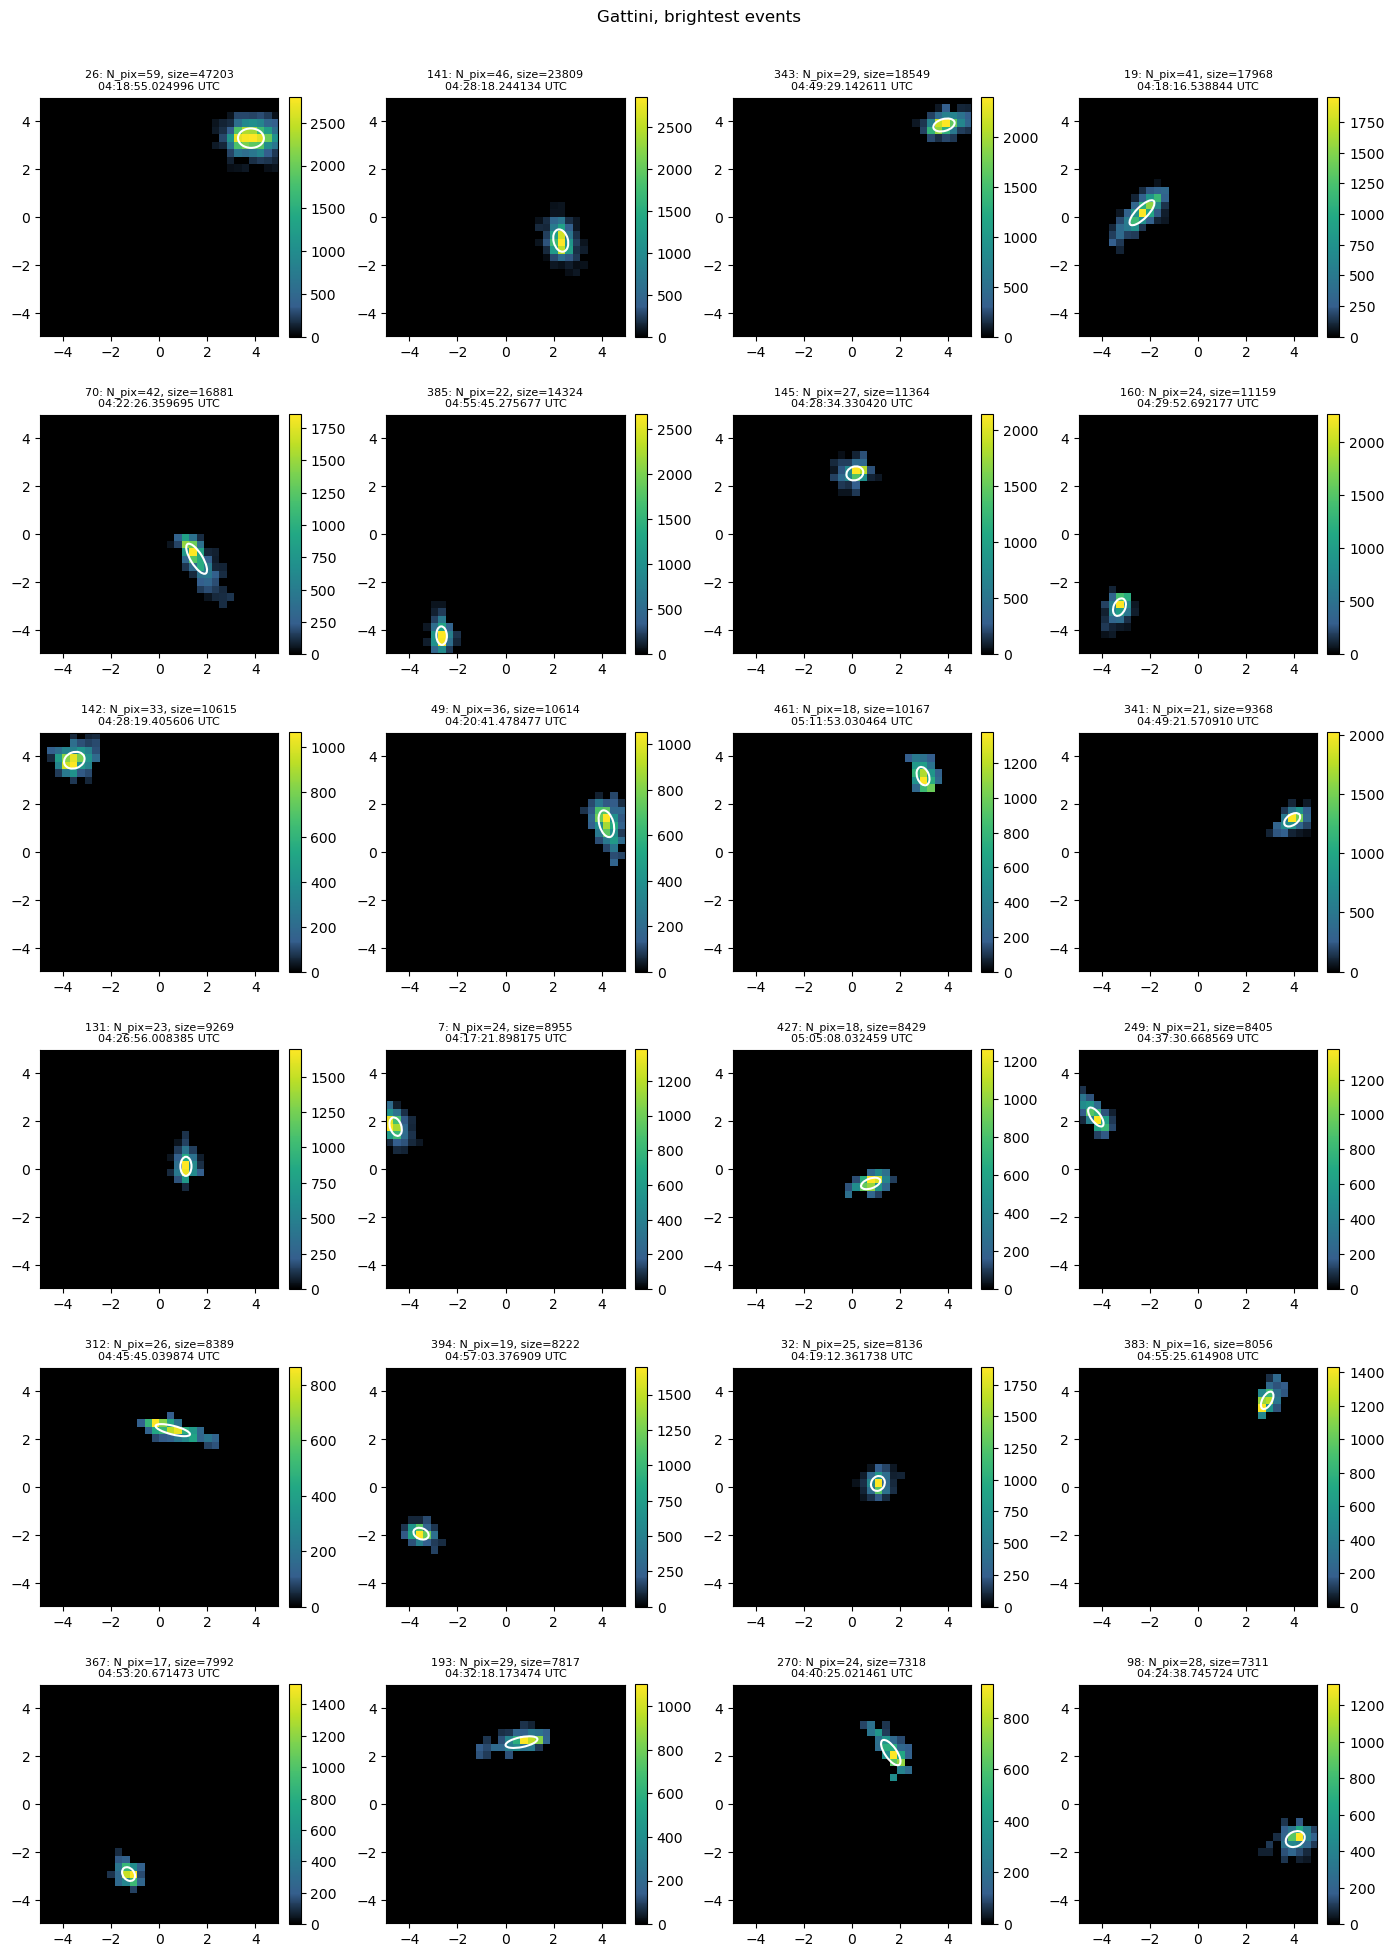

In [68]:
fig = dg.plot_image_grid(df, cut_images, df.nlargest(N_EVENTS, "size").index)
fig.suptitle(f"{TELESCOPE}, brightest events", y=1.02)
plt.show()

# Centroids
Image centroids after cuts, all steps together, one bin per camera pixel.

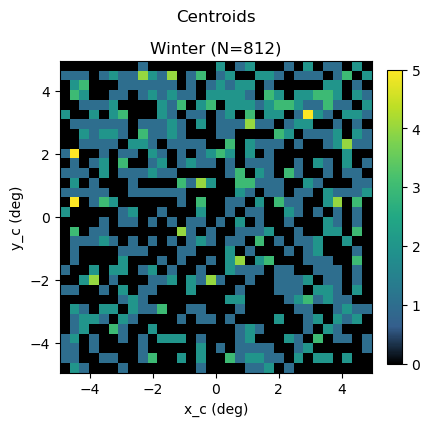

In [103]:
fig = dg.plot_centroids(df.assign(Telescope=TELESCOPE), title="Centroids")
plt.show()